# Scenario 1 Comparison Analysis

Compares the scenario 1 network for three different weather conditions 

In [3]:
import json
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os

In [4]:
home = "/home/lucakristin/Desktop/my_pypsa"
cluster = "450"
folder = "germany_scenario1_"

# Paths to the three networks
network_paths = {
    "windy": f"{home}/pypsa-eur/results/{folder}windy/networks/base_s_{cluster}_elec_.nc",
    "notwindy": f"{home}/pypsa-eur/results/{folder}notwindy/networks/base_s_{cluster}_elec_.nc",
    "windvariability": f"{home}/pypsa-eur/results/{folder}windvariability/networks/base_s_{cluster}_elec_.nc"
}

# Load the networks
networks = {name: pypsa.Network(path) for name, path in network_paths.items()}
n1 = networks["windy"]
n2 = networks["notwindy"]
n3 = networks["windvariability"]

n1.name = "Windy"
n2.name = "Not Windy"
n3.name = "Wind Variability"

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks


In [20]:
# --- Verification Step: Check if lines were extended ---
for name, n in networks.items():
    if "s_nom_opt" in n.lines:
        if n.lines.s_nom.equals(n.lines.s_nom_opt):
            print(f"Verification PASSED for '{name}' network: Line capacities were not extended (s_nom equals s_nom_opt).")
        else:
            diff_count = (n.lines.s_nom != n.lines.s_nom_opt).sum()
            print(f"Verification FAILED for '{name}' network: {diff_count} lines have different s_nom and s_nom_opt.")
    else:
        print(f"Verification NOTE for '{name}' network: No 's_nom_opt' column found; assuming lines were not extendable.")

Verification PASSED for 'windy' network: Line capacities were not extended (s_nom equals s_nom_opt).
Verification PASSED for 'not_windy' network: Line capacities were not extended (s_nom equals s_nom_opt).
Verification PASSED for 'wind_variability' network: Line capacities were not extended (s_nom equals s_nom_opt).


## Network statistics

### windy

In [22]:
n1.statistics()

Optimal Capacity  Installed Capacity  \
Generator   Combined-Cycle Gas        6.856780e+03        6.856780e+03   
            Offshore Wind (AC)        4.114068e+04        4.114068e+04   
            Onshore Wind              8.685255e+04        8.685255e+04   
            Open-Cycle Gas            2.285593e+03        2.285593e+03   
            Run of River              2.454727e+03        2.454727e+03   
            Solar                     5.713984e+04        5.713984e+04   
            biomass                   7.702450e+03        7.702450e+03   
            coal                      2.285593e+03        2.285593e+03   
            geothermal                2.285593e+01        2.285593e+01   
            lignite                   4.479763e+02        4.479763e+02   
            load                               inf                 inf   
            oil                       2.285593e+03        2.285593e+03   
            waste                     3.085551e+03        3.085551e+03   
Line        AC                        1.507647e+06        1.507647e+06   
Link        H2 Electrolysis           1.378741e+03        0.000000e+00   
            H2 Fuel Cell              1.110189e+03        0.000000e+00   
            battery charger           5.812567e+02        0.000000e+00   
            battery discharger        5.932427e+02        0.000000e+00   
Load        -                         0.000000e+00        0.000000e+00   
StorageUnit Pumped Hydro Storage      7.361720e+03        7.361720e+03   
            Reservoir & Dam           4.022382e+02        4.022382e+02   
Store       Battery Storage           3.016961e+03        0.000000e+00   
            Hydrogen Storage          7.719878e+02        0.000000e+00   

                                        Supply    Withdrawal  Energy Balance  \
Generator   Combined-Cycle Gas    3.524381e+03  0.000000e+00    3.524381e+03   
            Offshore Wind (AC)    4.489814e+04  0.000000e+00    4.489814e+04   
            Onshore Wind          1.035267e+06  0.000000e+00    1.035267e+06   
            Open-Cycle Gas        5.572708e+02  0.000000e+00    5.572708e+02   
            Run of River          2.414665e+04  0.000000e+00    2.414665e+04   
            Solar                 7.635022e+04  0.000000e+00    7.635022e+04   
            biomass               3.712826e+04  0.000000e+00    3.712826e+04   
            coal                  1.216332e+04  0.000000e+00    1.216332e+04   
            geothermal            3.894857e+02  0.000000e+00    3.894857e+02   
            lignite               5.617130e+00  0.000000e+00    5.617130e+00   
            load                  1.000000e-04  0.000000e+00    1.000000e-04   
            oil                   2.538000e-02  0.000000e+00    2.538000e-02   
            waste                 3.687025e+03  0.000000e+00    3.687025e+03   
Line        AC                    4.107280e+06  4.285138e+06   -1.778576e+05   
Link        H2 Electrolysis       0.000000e+00  3.308958e+04   -3.308958e+04   
            H2 Fuel Cell          0.000000e+00  2.314285e+04   -2.314285e+04   
            battery charger       0.000000e+00  3.813106e+03   -3.813106e+03   
            battery discharger    0.000000e+00  3.736065e+03   -3.736065e+03   
Load        -                     0.000000e+00  1.179665e+06   -1.179665e+06   
StorageUnit Pumped Hydro Storage  2.479668e+04  3.340920e+04   -8.612515e+03   
            Reservoir & Dam       2.794081e+03  0.000000e+00    2.794081e+03   
Store       Battery Storage       3.731878e+03  3.731878e+03    0.000000e+00   
            Hydrogen Storage      8.119365e+02  8.119365e+02    0.000000e+00   

                                  Transmission  Capacity Factor   Curtailment  \
Generator   Combined-Cycle Gas         0.00000     2.141664e-02  1.610383e+05   
            Offshore Wind (AC)         0.00000     4.547216e-02  8.256117e+05   
            Onshore Wind               0.00000     4.966592e-01  7.659002e+05   
            

###  not windy

In [24]:
n2.statistics()

Optimal Capacity  Installed Capacity  \
Generator   Combined-Cycle Gas        6.856780e+03        6.856780e+03   
            Offshore Wind (AC)        4.114068e+04        4.114068e+04   
            Onshore Wind              8.685255e+04        8.685255e+04   
            Open-Cycle Gas            2.285593e+03        2.285593e+03   
            Run of River              2.454727e+03        2.454727e+03   
            Solar                     5.713984e+04        5.713984e+04   
            biomass                   7.702450e+03        7.702450e+03   
            coal                      2.285593e+03        2.285593e+03   
            geothermal                2.285593e+01        2.285593e+01   
            lignite                   4.479763e+02        4.479763e+02   
            load                               inf                 inf   
            oil                       2.285593e+03        2.285593e+03   
            waste                     3.085551e+03        3.085551e+03   
Line        AC                        1.507647e+06        1.507647e+06   
Link        H2 Electrolysis           1.664226e+02        0.000000e+00   
            H2 Fuel Cell              1.401100e-01        0.000000e+00   
            battery charger           1.674060e+04        0.000000e+00   
            battery discharger        1.708580e+04        0.000000e+00   
Load        -                         0.000000e+00        0.000000e+00   
StorageUnit Pumped Hydro Storage      7.361720e+03        7.361720e+03   
            Reservoir & Dam           4.022382e+02        4.022382e+02   
Store       Battery Storage           4.741384e+04        0.000000e+00   
            Hydrogen Storage          4.582860e+05        0.000000e+00   

                                        Supply    Withdrawal  Energy Balance  \
Generator   Combined-Cycle Gas    1.645623e+05  0.000000e+00    1.645623e+05   
            Offshore Wind (AC)    3.064848e+04  0.000000e+00    3.064848e+04   
            Onshore Wind          5.854971e+04  0.000000e+00    5.854971e+04   
            Open-Cycle Gas        5.485362e+04  0.000000e+00    5.485362e+04   
            Run of River          3.905883e+04  0.000000e+00    3.905883e+04   
            Solar                 2.897599e+05  0.000000e+00    2.897599e+05   
            biomass               1.848582e+05  0.000000e+00    1.848582e+05   
            coal                  5.485419e+04  0.000000e+00    5.485419e+04   
            geothermal            5.485362e+02  0.000000e+00    5.485362e+02   
            lignite               1.075139e+04  0.000000e+00    1.075139e+04   
            load                  2.793384e+05  0.000000e+00    2.793384e+05   
            oil                   5.485366e+04  0.000000e+00    5.485366e+04   
            waste                 7.405302e+04  0.000000e+00    7.405302e+04   
Line        AC                    1.171301e+06  1.264012e+06   -9.271096e+04   
Link        H2 Electrolysis       0.000000e+00  1.382430e+00   -1.382430e+00   
            H2 Fuel Cell          0.000000e+00  3.320460e+00   -3.320460e+00   
            battery charger       0.000000e+00  4.304332e+04   -4.304332e+04   
            battery discharger    0.000000e+00  4.222236e+04   -4.222236e+04   
Load        -                     0.000000e+00  1.300023e+06   -1.300023e+06   
StorageUnit Pumped Hydro Storage  0.000000e+00  5.921000e-02   -5.921000e-02   
            Reservoir & Dam       5.760239e+03  0.000000e+00    5.760239e+03   
Store       Battery Storage       4.216235e+04  4.216235e+04    0.000000e+00   
            Hydrogen Storage      3.470000e-02  3.470000e-02    0.000000e+00   

                                  Transmission  Capacity Factor   Curtailment  \
Generator   Combined-Cycle Gas         0.00000     9.999977e-01  3.830200e-01   
            Offshore Wind (AC)         0.00000     3.104032e-02  3.580000e-03   
            Onshore Wind               0.00000     2.808865e-02  2.661200e-01   
            

### wind variability

In [25]:
n3.statistics()

Optimal Capacity  Installed Capacity  \
Generator   Combined-Cycle Gas        6.856780e+03        6.856780e+03   
            Offshore Wind (AC)        4.114068e+04        4.114068e+04   
            Onshore Wind              8.685255e+04        8.685255e+04   
            Open-Cycle Gas            2.285593e+03        2.285593e+03   
            Run of River              2.454727e+03        2.454727e+03   
            Solar                     5.713984e+04        5.713984e+04   
            biomass                   7.702450e+03        7.702450e+03   
            coal                      2.285593e+03        2.285593e+03   
            geothermal                2.285593e+01        2.285593e+01   
            lignite                   4.479763e+02        4.479763e+02   
            load                               inf                 inf   
            oil                       2.285593e+03        2.285593e+03   
            waste                     3.085551e+03        3.085551e+03   
Line        AC                        1.507647e+06        1.507647e+06   
Link        H2 Electrolysis           8.624761e+03        0.000000e+00   
            H2 Fuel Cell              1.542589e+04        0.000000e+00   
            battery charger           2.522780e+04        0.000000e+00   
            battery discharger        2.574801e+04        0.000000e+00   
Load        -                         0.000000e+00        0.000000e+00   
StorageUnit Pumped Hydro Storage      7.361720e+03        7.361720e+03   
            Reservoir & Dam           4.022382e+02        4.022382e+02   
Store       Battery Storage           1.313731e+05        0.000000e+00   
            Hydrogen Storage          1.335262e+05        0.000000e+00   

                                        Supply    Withdrawal  Energy Balance  \
Generator   Combined-Cycle Gas    1.384809e+05  0.000000e+00    1.384809e+05   
            Offshore Wind (AC)    1.404369e+05  0.000000e+00    1.404369e+05   
            Onshore Wind          8.254707e+05  0.000000e+00    8.254707e+05   
            Open-Cycle Gas        3.800081e+04  0.000000e+00    3.800081e+04   
            Run of River          1.584587e+04  0.000000e+00    1.584587e+04   
            Solar                 5.410327e+04  0.000000e+00    5.410327e+04   
            biomass               1.369217e+05  0.000000e+00    1.369217e+05   
            coal                  4.599935e+04  0.000000e+00    4.599935e+04   
            geothermal            4.520287e+02  0.000000e+00    4.520287e+02   
            lignite               1.022338e+04  0.000000e+00    1.022338e+04   
            load                  4.473704e+04  0.000000e+00    4.473704e+04   
            oil                   4.224984e+04  0.000000e+00    4.224984e+04   
            waste                 5.788419e+04  0.000000e+00    5.788419e+04   
Line        AC                    5.066235e+06  5.187237e+06   -1.210020e+05   
Link        H2 Electrolysis       0.000000e+00  2.061922e+05   -2.061922e+05   
            H2 Fuel Cell          0.000000e+00  1.442111e+05   -1.442111e+05   
            battery charger       0.000000e+00  1.932757e+05   -1.932757e+05   
            battery discharger    0.000000e+00  1.893713e+05   -1.893713e+05   
Load        -                     0.000000e+00  1.368958e+06   -1.368958e+06   
StorageUnit Pumped Hydro Storage  1.288238e+03  2.196738e+03   -9.085005e+02   
            Reservoir & Dam       1.947115e+03  0.000000e+00    1.947115e+03   
Store       Battery Storage       1.348235e+05  1.348235e+05    0.000000e+00   
            Hydrogen Storage      4.845005e+04  4.845005e+04    0.000000e+00   

                                  Transmission  Capacity Factor   Curtailment  \
Generator   Combined-Cycle Gas         0.00000         0.841508  2.608183e+04   
            Offshore Wind (AC)         0.00000         0.142232  4.991996e+05   
            Onshore Wind               0.00000         0.396012  1.277495e+05   
            

load: 
- Supply (4.47e+04): This is the total amount of energy that was not served to the consumers during the simulation period (i.e., the total energy of the blackouts).

- Market Value (99999.10): This is the average price of electricity during the hours when load was shed. It is extremely high because it's set by the marginal cost of the most expensive "generator" in the system—the load-shedding generator itself.

### Grid Congestion and Curtailment

##### Marginal Prices

Plotting 'Windy' network at time 2025-10-26 15:00:00 with peak marginal price 90.02 €/MWh
Plotting 'Not Windy' network at time 2025-04-08 05:00:00 with peak marginal price 100000.00 €/MWh
Plotting 'Wind Variability' network at time 2025-10-06 07:00:00 with peak marginal price 100000.01 €/MWh


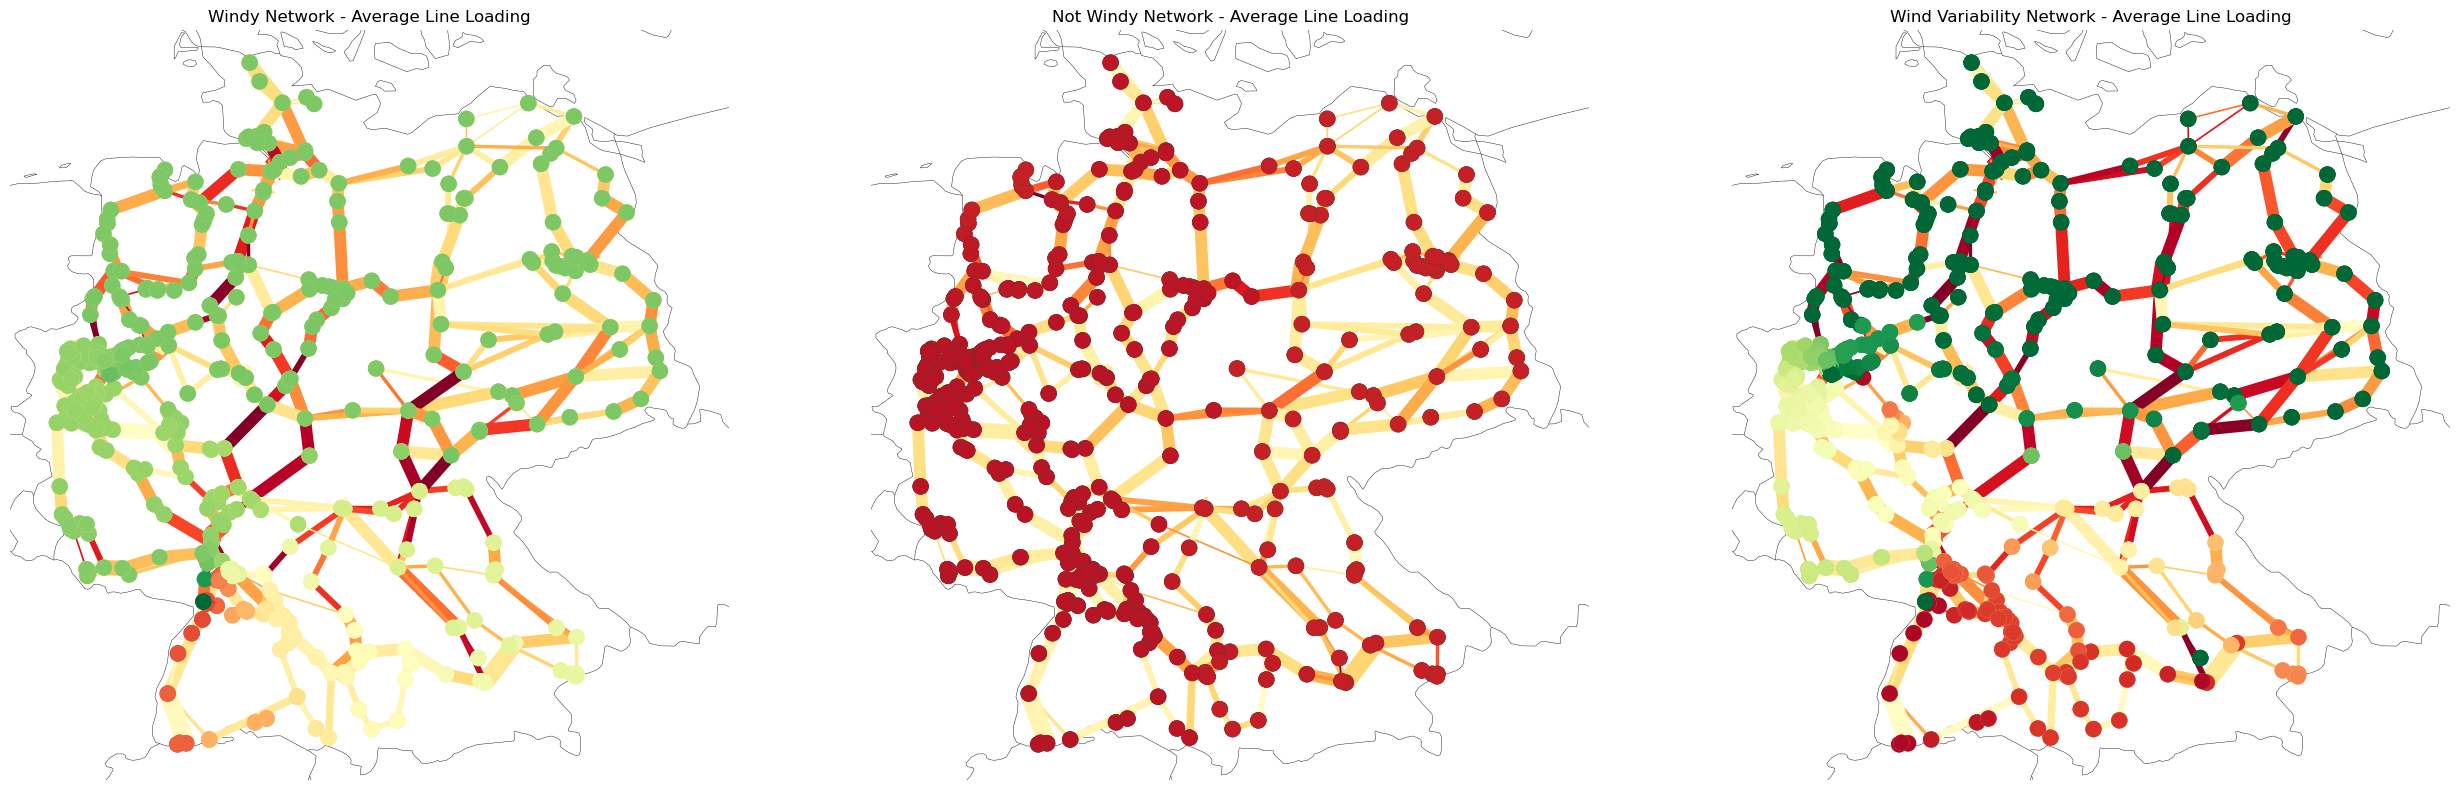

In [21]:
# --- Calculate average loading across all snapshots ---
avg_loading_n1 = (n1.lines_t.p0.abs() / n1.lines.s_nom).mean()
avg_loading_n2 = (n2.lines_t.p0.abs() / n2.lines.s_nom).mean()
avg_loading_n3 = (n3.lines_t.p0.abs() / n3.lines.s_nom).mean()

# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_congestion(n, loading_avg, ax, title):
    
    # Find the time with the highest overall marginal price
    peak_price_time = n.buses_t.marginal_price.max(axis=1).idxmax()
    peak_prices = n.buses_t.marginal_price.loc[peak_price_time]
    print(f"Plotting '{n.name}' network at time {peak_price_time} with peak marginal price {peak_prices.max():.2f} €/MWh")
    
    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=0.01, # Size buses by marginal price
        bus_colors=peak_prices,       # Color buses by marginal price
        bus_cmap='RdYlGn_r',
        line_colors=loading_avg,
        line_cmap="YlOrRd",
        line_width=n.lines.s_nom / 400,
        link_width=n.links.p_nom / 400 if not n.links.empty else 0,
    )

# Plot Average Loading Over All Snapshots for each network
plot_network_congestion(n1, avg_loading_n1, axes[0], "Windy Network - Average Line Loading")
plot_network_congestion(n2, avg_loading_n2, axes[1], "Not Windy Network - Average Line Loading")
plot_network_congestion(n3, avg_loading_n3, axes[2], "Wind Variability Network - Average Line Loading")

plt.tight_layout()
plt.show()

### Load shedding

Using load-related carriers: ['load']
Using load-related carriers: ['load']
Using load-related carriers: ['load']


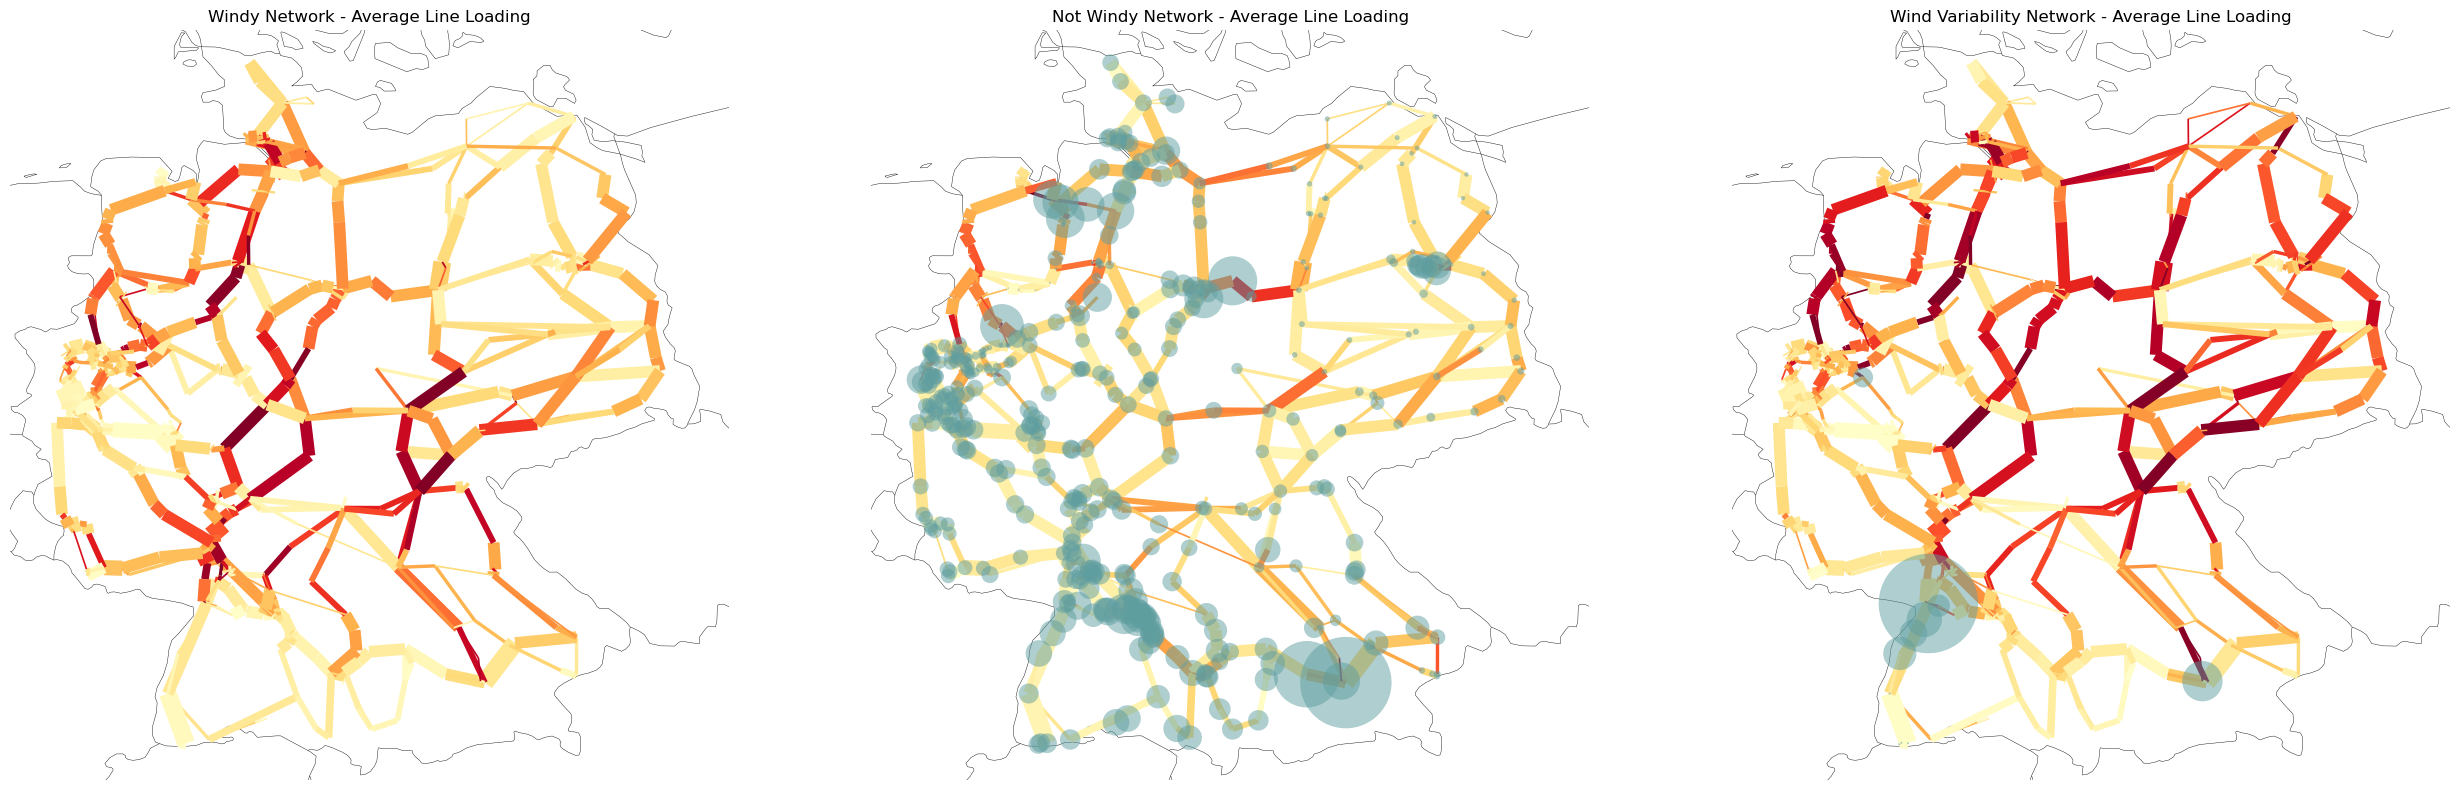

In [41]:
# --- Calculate average loading across all snapshots ---
avg_loading_n1 = (n1.lines_t.p0.abs() / n1.lines.s_nom).mean()
avg_loading_n2 = (n2.lines_t.p0.abs() / n2.lines.s_nom).mean()
avg_loading_n3 = (n3.lines_t.p0.abs() / n3.lines.s_nom).mean()

# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_congestion(n, loading_avg, ax, title):
    load_mask = n.generators.carrier.str.contains("load", case=False, na=False)
    shed_gens = n.generators.index[load_mask]

    if len(shed_gens) == 0:
        print("No generator carrier containing 'load' found. Plot will show zeros.")
        shed_by_bus_time = pd.DataFrame(
            0.0, index=n.snapshots, columns=n.buses.index
        )
    else:
        used_carriers = sorted(n.generators.loc[shed_gens, "carrier"].unique())
        print(f"Using load-related carriers: {used_carriers}")

        # Time series of unmet load aggregated by bus [MW].
        shed_by_bus_time = (
            n.generators_t.p[shed_gens]
            .T.groupby(n.generators.loc[shed_gens, "bus"])
            .sum()
            .T
            .reindex(columns=n.buses.index, fill_value=0.0)
        )


    # Pick the snapshot with the highest system-wide unmet load.
    total_shed = shed_by_bus_time.sum(axis=1)
    worst_shed_snapshot = total_shed.idxmax()
    unmet_load_at_snapshot = shed_by_bus_time.loc[worst_shed_snapshot]


    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        #bus_sizes=0.01, # Size buses by unmet load at worst snapshot
        bus_sizes=unmet_load_at_snapshot/5000,
        #bus_colors=unmet_load_at_snapshot,
        bus_alpha=0.5,
        bus_cmap="YlOrRd",
        line_colors=loading_avg,
        line_cmap="YlOrRd",
        line_width=n.lines.s_nom / 400,
        link_width=n.links.p_nom / 400 if not n.links.empty else 0,
    )

# Plot Average Loading Over All Snapshots for each network
plot_network_congestion(n1, avg_loading_n1, axes[0], "Windy Network - Average Line Loading")
plot_network_congestion(n2, avg_loading_n2, axes[1], "Not Windy Network - Average Line Loading")
plot_network_congestion(n3, avg_loading_n3, axes[2], "Wind Variability Network - Average Line Loading")

plt.tight_layout()
plt.show()

In [29]:
# --- Print congestion statistics ---
print("\n" + "=" * 70)
print("CONGESTION STATISTICS")
print("=" * 70)
print(f"\nWindy Network:")
print(f"  Average loading across all lines: {avg_loading_n1.mean():.2%}")
print(f"  Max average loading: {avg_loading_n1.max():.2%}")
print(f"  Lines with >60% avg loading: {(avg_loading_n1 > 0.6).sum()}")
print(f"  Lines with >70% avg loading: {(avg_loading_n1 > 0.7).sum()}")

print(f"\nNot Windy Network:")
print(f"  Average loading across all lines: {avg_loading_n2.mean():.2%}")
print(f"  Max average loading: {avg_loading_n2.max():.2%}")
print(f"  Lines with >60% avg loading: {(avg_loading_n2 > 0.6).sum()}")
print(f"  Lines with >70% avg loading: {(avg_loading_n2 > 0.7).sum()}")

print(f"\nWind Variability Network:")
print(f"  Average loading across all lines: {avg_loading_n3.mean():.2%}")
print(f"  Max average loading: {avg_loading_n3.max():.2%}")
print(f"  Lines with >60% avg loading: {(avg_loading_n3 > 0.6).sum()}")
print(f"  Lines with >70% avg loading: {(avg_loading_n3 > 0.7).sum()}")
print("=" * 70)


CONGESTION STATISTICS

Windy Network:
  Average loading across all lines: 23.93%
  Max average loading: 69.92%
  Lines with >60% avg loading: 34
  Lines with >70% avg loading: 0

Not Windy Network:
  Average loading across all lines: 7.21%
  Max average loading: 29.28%
  Lines with >60% avg loading: 0
  Lines with >70% avg loading: 0

Wind Variability Network:
  Average loading across all lines: 28.85%
  Max average loading: 69.98%
  Lines with >60% avg loading: 58
  Lines with >70% avg loading: 0


##### Offshore Wind Curtailment

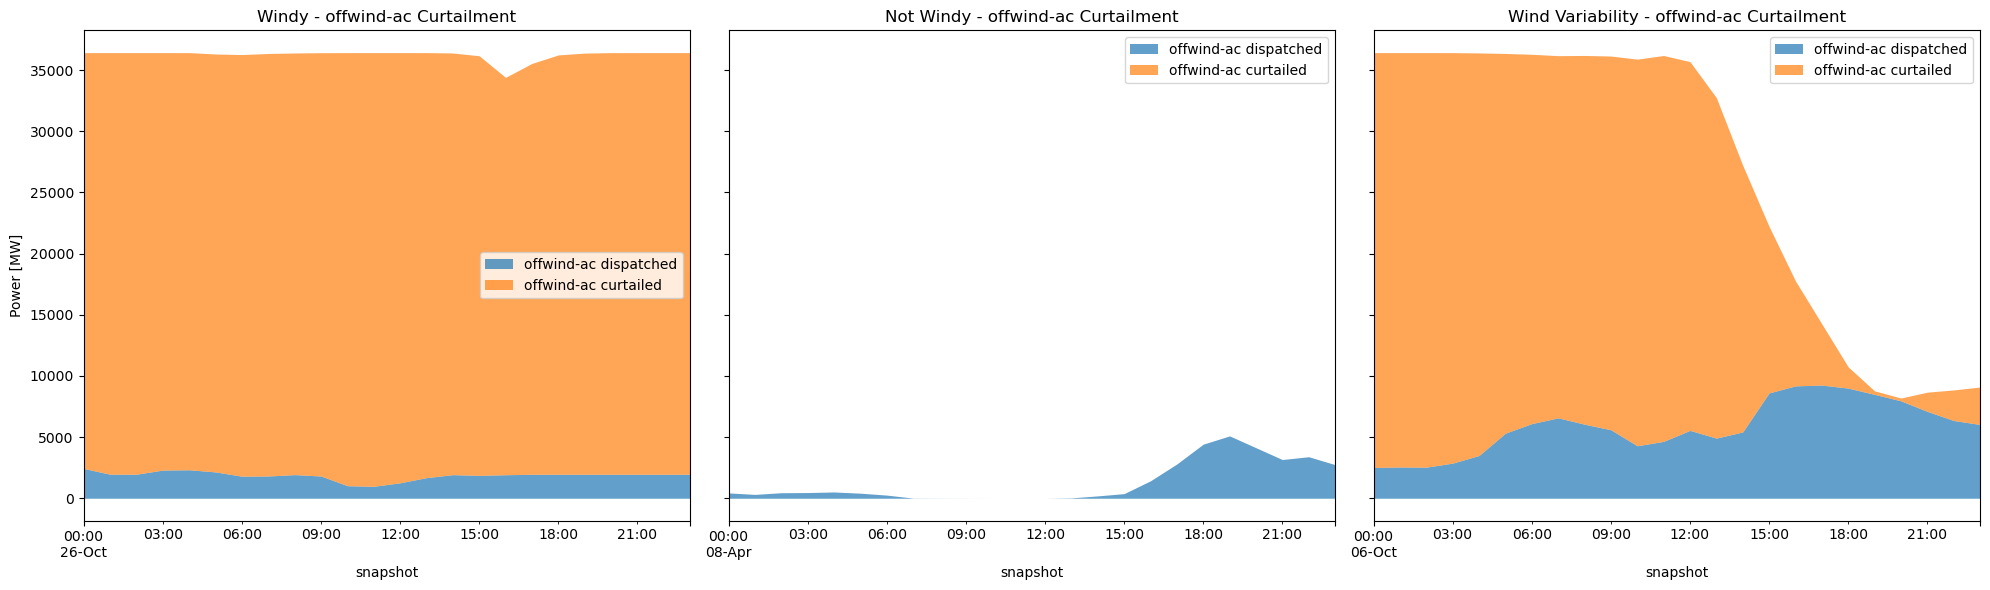

In [42]:
def plot_curtailment(n, carrier, ax):
    p_available = n.generators_t.p_max_pu.multiply(n.generators.p_nom).T.groupby(n.generators.carrier).sum().T
    p_dispatched = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    p_curtailed = p_available - p_dispatched
    
    # Correct for any minor negative values from floating point inaccuracies
    p_curtailed[p_curtailed < 0] = 0
    
    df = pd.DataFrame({
        f"{carrier} dispatched": p_dispatched[carrier],
        f"{carrier} curtailed": p_curtailed[carrier]
    })
    
    df.plot(kind="area", ax=ax, lw=0, alpha=0.7)
    ax.set_title(f"{n.name} - {carrier} Curtailment")
    ax.set_ylabel("Power [MW]")

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

plot_curtailment(n1, "offwind-ac", axes[0])
plot_curtailment(n2, "offwind-ac", axes[1])
plot_curtailment(n3, "offwind-ac", axes[2])


plt.tight_layout()
plt.show()

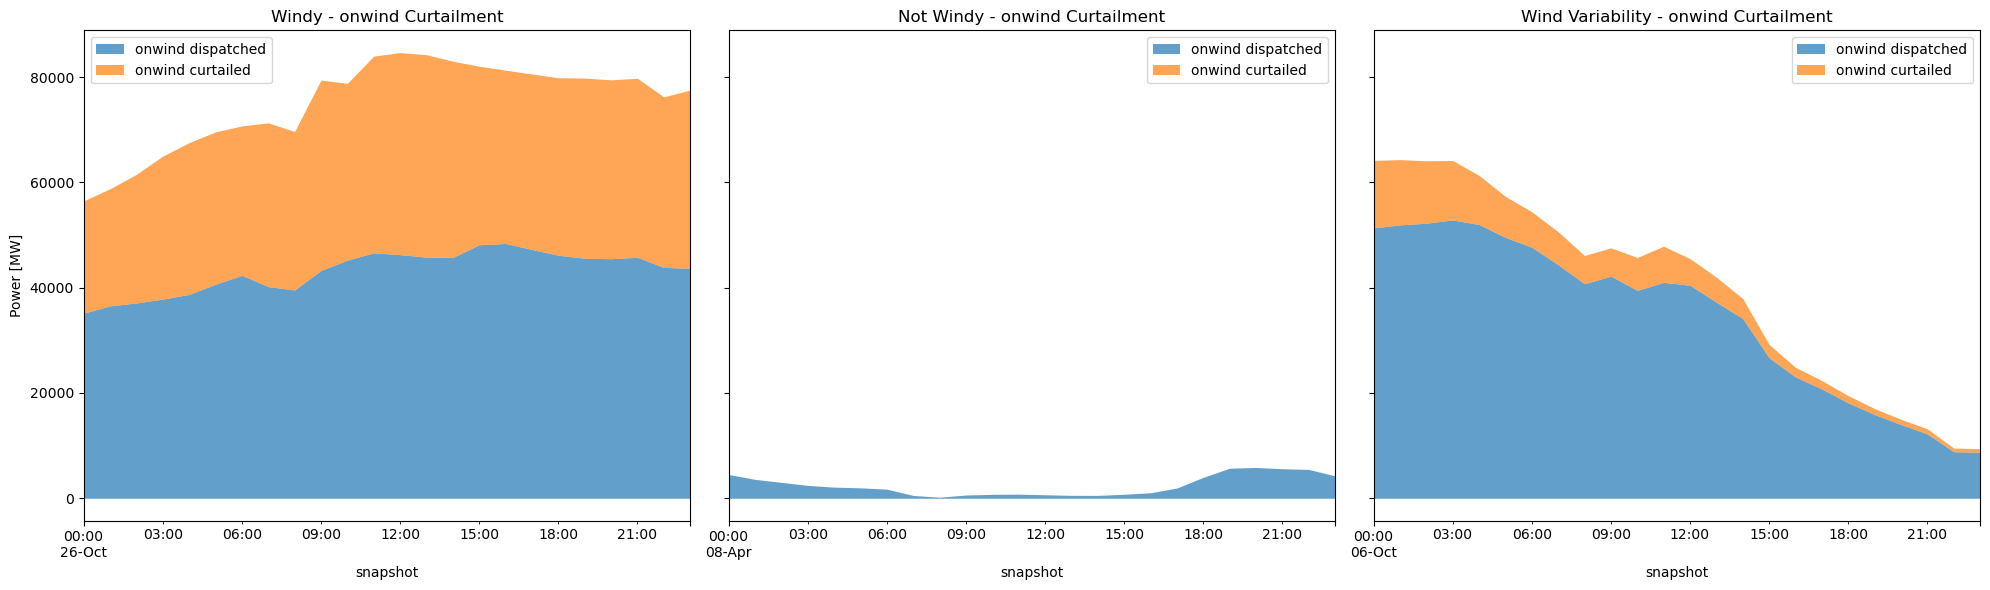

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

plot_curtailment(n1, "onwind", axes[0])
plot_curtailment(n2, "onwind", axes[1])
plot_curtailment(n3, "onwind", axes[2])

plt.tight_layout()
plt.show()

### 4.2 Generation and Capacity Comparison

##### Power Dispatch by Carrier

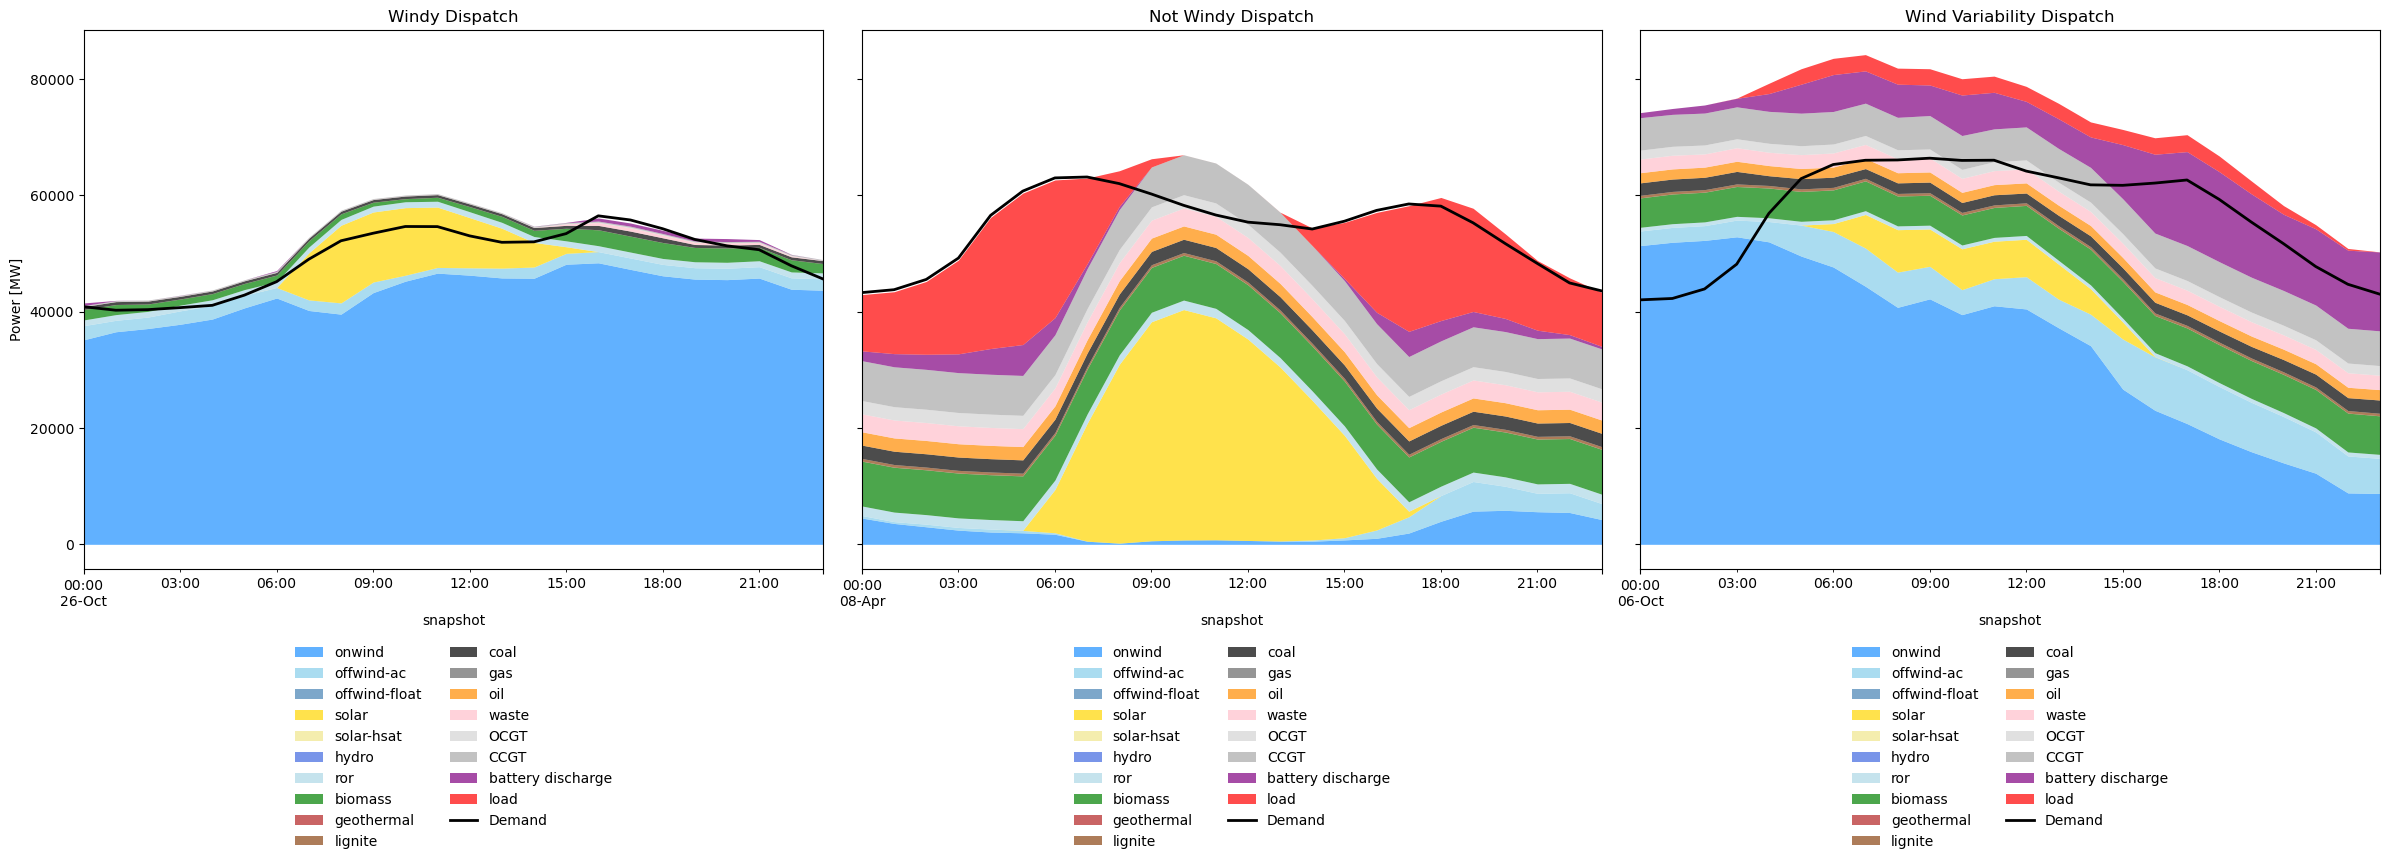

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)

# --- Define Colors and Order ---
colors = {
    # Wind
    "onwind": "dodgerblue",
    "offwind-ac": "skyblue",
    "offwind-float": "steelblue",
    # Solar
    "solar": "gold",
    "solar-hsat": "khaki",
    # Hydro
    "hydro": "royalblue",
    "ror": "lightblue",
    # Fossil Fuels
    "lignite": "saddlebrown",
    "coal": "black",
    "gas": "dimgray",
    "oil": "darkorange",
    "OCGT": "lightgray",
    "CCGT": "darkgray",
    # Other
    "biomass": "green",
    "waste": "pink",
    "geothermal": "firebrick",
    "battery discharge": "purple",
    "load": "red"
}

cols = [
    # Renewables
    "onwind", "offwind-ac", "offwind-float", 
    "solar", "solar-hsat",
    "hydro", "ror",
    "biomass", "geothermal",
    # Conventional
    "lignite", "coal", "gas", "oil", "waste",
    "OCGT", "CCGT",
    # Storage
    "battery discharge",
    "load"
]

# --- Helper function for plotting ---
def plot_dispatch(n, ax, title):
    p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T

    # Add battery discharge as another stacked supply source on the electricity side
    battery_discharge_dispatch = pd.Series(0.0, index=n.snapshots)
    if not n.links.empty and "battery discharger" in set(n.links.carrier):
        battery_discharge_dispatch = -n.links_t.p1.loc[:, n.links.carrier == "battery discharger"].sum(axis=1)

    p_by_carrier["battery discharge"] = battery_discharge_dispatch

    # Reorder and fill missing columns
    p_by_carrier = p_by_carrier.reindex(columns=cols).fillna(0)

    # Get colors in the correct order
    c = [colors.get(col, "gray") for col in p_by_carrier.columns]

    p_by_carrier.plot(kind="area", ax=ax, lw=0, title=title, color=c, alpha=0.7)

    # Add demand curve
    demand = n.loads_t.p_set.sum(axis=1)
    demand.plot(ax=ax, color="black", lw=2, label="Demand")

    ax.set_ylabel("Power [MW]")
    ax.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)

# --- Plotting ---
plot_dispatch(n1, axes[0], "Windy Dispatch")
plot_dispatch(n2, axes[1], "Not Windy Dispatch")
plot_dispatch(n3, axes[2], "Wind Variability Dispatch")


plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

##### Total Energy Production by Carrier

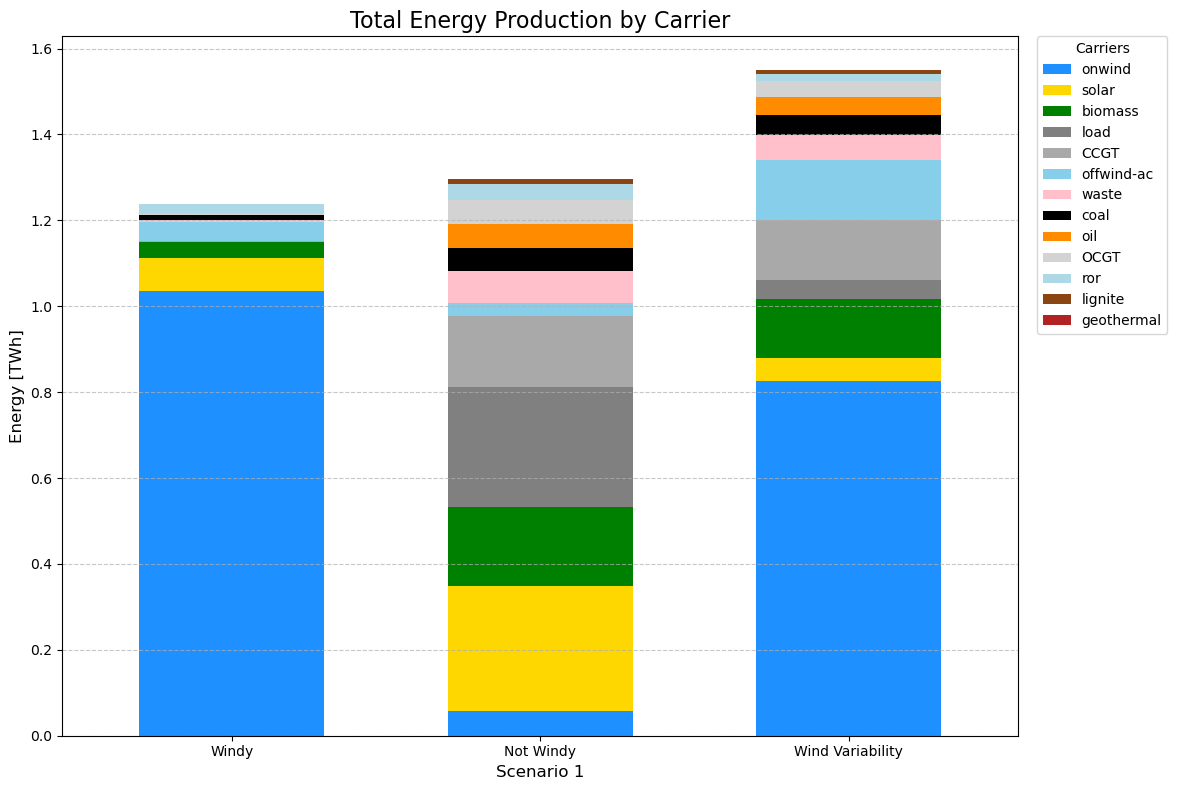

In [33]:
# --- Calculate energy production for each scenario ---
p_by_carrier_n1 = n1.generators_t.p.sum().groupby(n1.generators.carrier).sum()
p_by_carrier_n2 = n2.generators_t.p.sum().groupby(n2.generators.carrier).sum()
p_by_carrier_n3 = n3.generators_t.p.sum().groupby(n3.generators.carrier).sum()

# --- Create a DataFrame for plotting ---
energy_df = pd.DataFrame({
    "Windy": p_by_carrier_n1,
    "Not Windy": p_by_carrier_n2,
    "Wind Variability": p_by_carrier_n3
}).fillna(0)

# Filter out carriers with negligible energy
energy_df = energy_df[energy_df.sum(axis=1) > 0.1]

# --- Sort carriers by total energy production (descending) ---
energy_df = energy_df.loc[energy_df.sum(axis=1).sort_values(ascending=False).index]


# Get colors for the carriers that are present
bar_colors = [colors.get(carrier, "grey") for carrier in energy_df.index]

# --- Plotting ---
fig, ax = plt.subplots(figsize=(14, 8))

# Plot stacked bar chart
(energy_df.T / 1e6).plot(kind="bar", stacked=True, ax=ax, color=bar_colors, width=0.6)

# --- Formatting ---
ax.set_title("Total Energy Production by Carrier", fontsize=16)
ax.set_ylabel("Energy [TWh]", fontsize=12)
ax.set_xlabel("Scenario 1", fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# --- Legend ---
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, 
    labels, 
    title="Carriers",
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    borderaxespad=0.
)

plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legend
plt.show()

## CO2 emissions 

In [ ]:
def calculate_emissions(n):
    emission_factors = n.c.carriers.static.co2_emissions
    emitting_generators = n.c.generators.static[
        n.c.generators.static.carrier.map(emission_factors).fillna(0) != 0
    ]
    generator_p = n.c.generators.dynamic.p.loc[:, emitting_generators.index]
    generator_efficiency = n.c.generators._as_dynamic("efficiency").loc[:, emitting_generators.index]
    snapshot_weightings = n.snapshot_weightings.generators.reindex(generator_p.index)
    emission_factors_per_generator = emitting_generators.carrier.map(emission_factors)
    co2_emissions = (
        generator_p.multiply(snapshot_weightings, axis=0)
        .multiply(emission_factors_per_generator, axis=1)
        .divide(generator_efficiency)
        .sum()
        .sum()
    )
    return co2_emissions

In [1]:
for n in networks.values():
    print(f"Total CO2 emissions at the {n.name} day: {calculate_emissions(n):.2f} kg CO2")

NameError: name 'networks' is not defined

In [10]:
calculate_emissions(n2)

Total CO2 emissions at the Not Windy day: 257655.35


In [11]:
calculate_emissions(n3)

Total CO2 emissions at the Wind Variability day: 206274.87
